In [3]:
using Pkg
Pkg.add(url="https://github.com/fernandopenaranda/Optics_in_the_length_gauge")

    Updating git-repo `https://github.com/fernandopenaranda/Optics_in_the_length_gauge`
   Resolving package versions...
    Updating `~/Documents/Work/PostdocDonosti/Packages/LMC/Project.toml`
  [0ea70cc5] ~ Optics_in_the_length_gauge v1.0.0-DEV `https://github.com/fernandopenaranda/Optics_in_the_length_gauge#main` ⇒ v1.0.0-DEV `https://github.com/fernandopenaranda/Optics_in_the_length_gauge#main`
    Updating `~/Documents/Work/PostdocDonosti/Packages/LMC/Manifest.toml`
  [0ea70cc5] ~ Optics_in_the_length_gauge v1.0.0-DEV `https://github.com/fernandopenaranda/Optics_in_the_length_gauge#main` ⇒ v1.0.0-DEV `https://github.com/fernandopenaranda/Optics_in_the_length_gauge#main`
Precompiling project...
  ✓ Optics_in_the_length_gauge
  ✓ LMC
  2 dependencies successfully precompiled in 7 seconds. 186 already precompiled.
  2 dependencies precompiled but different versions are currently loaded. Restart julia to access the new versions


In [1]:
using Pkg
Pkg.activate(dirname(dirname(pwd())))   # activate MyPackage
# Pkg.instantiate()
using Revise
using LMC
using LinearAlgebra
using Optics_in_the_length_gauge
# using CairoMakie

  Activating project at `~/Documents/Work/PostdocDonosti/Packages/LMC`


In [2]:
using CairoMakie, Colors

Loaded plotting extension


## Cluster

In [ ]:
# important everytime you update a program
rm -rf /scratch/$USER/julia_depot/compiled
julia --project=. -e 'using Pkg; Pkg.instantiate(); Pkg.precompile()'

# copy from cluster to local
# rsync -avz ferpe@hyperion.sw.ehu.es:/dipc/ferpe/Projects/LMC /Users/fernandopenaranda/Documents/Work/PostdocDonosti/Packages/LMC/src/Paper/ClusterTBG/output

In [3]:
#input self-consistent data (band structures and fillings)
folder = 2281278
simportedvp  =  LMC.provide_folder_get_observables_atlas_reshuffled(folder,"vp")
simportedqah =  LMC.provide_folder_get_observables_atlas_reshuffled(folder,"qah")
s = simportedvp

Self_consistent_data([[0.09177345774687988, 0.9082266953889119, 0.09177332560351777, 0.9082265632458201, 0.09177345774707828, 0.9082266953886995, 0.09177332560324447, 0.90822656324608], [0.09511348277570118, 0.9082511047894717, 0.09488496101520044, 0.9082363274508053, 0.09506482891973579, 0.9082485860070545, 0.09488496101520041, 0.9082363274508], [0.09837451965982014, 0.9082578457346432, 0.09819466351798244, 0.9082466677698788, 0.09837451965980154, 0.9082578457346596, 0.09819466212611173, 0.908246668566111], [0.10245915358429471, 0.9083252464279664, 0.10138957737766345, 0.9082700970840478, 0.1014245880034912, 0.9082721917421305, 0.10138957737766344, 0.908270097084047], [0.1063219445813836, 0.908357447941392, 0.10450540358549186, 0.9082591487666652, 0.10465143137966329, 0.9082700749993093, 0.10450540358549182, 0.908259148766665], [0.10919545986212188, 0.9083505993834553, 0.10789113601393205, 0.9082876665175774, 0.10893827608404896, 0.9083380869167671, 0.107891136013932, 0.90828766651757

In [4]:
l = LMC.readparams(folder)
pimported = ParamsHF(paramsHF(1.05, 1,  1),
    μ = 0,
    nf = l.nf[1],
    λ = l.λ[1],
    M = l.M[1],
    v = l.v[1],
    vp = l.vp[1],
    γ =l.γ[1],
    sigmaz = l.sigmaz[1],
    sigmazlayerz = l.sigmazlayerz[1],
    U1 = l.U1[1],
    U2 = l.U2[1],
    J = 0*l.J[1],
    VP =l.VP[1],
    twovalleystwospins= l.twovalleystwospins[1]);

In [147]:
# HYP Drudes: 
drude_vec = [4637376]
# HYP LMC: [ 4616767, 4617898 , 4618700,  4619343]
lmc_vec = [4658685,4657197, 4656436, 4652639,4651517,4650903,4650379,4649541,4648753]

#out put response calculations
drudePID = drude_vec[1]#4619927#4612639 #4604805
lmcPID = lmc_vec[1]

drudepath = "/Users/fernandopenaranda/Documents/Work/PostdocDonosti/Packages/LMC/src/Paper/ClusterTBG/output/LMC/$(drudePID)_merged_data.jld"
drudepresetpath = "/Users/fernandopenaranda/Documents/Work/PostdocDonosti/Packages/LMC/src/Paper/ClusterTBG/output/LMC/$(drudePID)_merged_presets.jld"
lmcpath = "/Users/fernandopenaranda/Documents/Work/PostdocDonosti/Packages/LMC/src/Paper/ClusterTBG/output/LMC/$(lmcPID)_merged_data.jld"
lmcpresetpath = "/Users/fernandopenaranda/Documents/Work/PostdocDonosti/Packages/LMC/src/Paper/ClusterTBG/output/LMC/$(lmcPID)_merged_presets.jld"


"/Users/fernandopenaranda/Documents/Work/PostdocDonosti/Packages/LMC/src/Paper/ClusterTBG/output/LMC/4658685_merged_presets.jld"

In [ ]:
l = xxx_lmc_presets(ParamsHF(pimported, μ = s.mus[20]), diagm(s.ofmats[20]), T = 1, evals = 19);

## Calculations

In [6]:
@time vorbs = lmc_orb_sweep(folder, "vp", evals = 100, T = 5);

progress: 0.05 |  val: 0.024336788815426103
progress: 0.1 |  val: -0.004824911446634754
progress: 0.15 |  val: -0.014572792069551092
progress: 0.2 |  val: -0.0017250418020045915
progress: 0.25 |  val: 0.00048080626150761186
progress: 0.3 |  val: 0.012854626743452372
progress: 0.35 |  val: 0.006698691682365698
progress: 0.4 |  val: 0.002584548192946072
progress: 0.45 |  val: -0.003607916133660487
progress: 0.5 |  val: 0.0038453646841915485
progress: 0.55 |  val: 0.008165949524903644
progress: 0.6 |  val: 0.026802429452176695
progress: 0.65 |  val: 0.07167743843273816
progress: 0.7 |  val: 0.0019110455446832344
progress: 0.75 |  val: 0.03761503732506724
progress: 0.8 |  val: 0.02467225893938866
progress: 0.85 |  val: 0.001466498055876914
progress: 0.9 |  val: -0.0029118937653688426
progress: 0.95 |  val: 0.022684859456923494
progress: 1.0 |  val: -0.014439818883923596
 79.352296 seconds (8.89 M allocations: 45.104 GiB, 5.88% gc time)


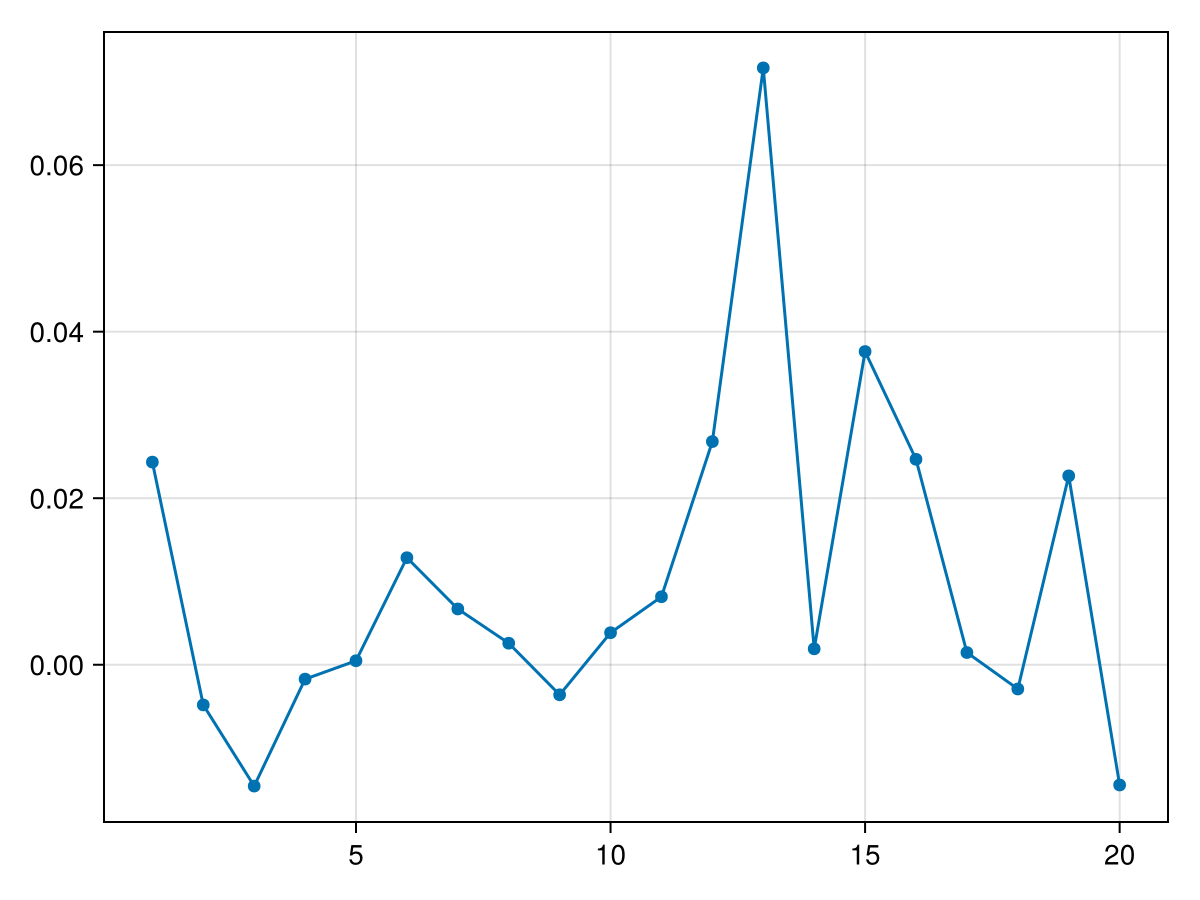

In [13]:
fig = Figure()
ax = Axis(fig[1,1])
lines!(ax,  [v for v in vorbs[2]] )
scatter!(ax,  [v for v in vorbs[2]] )
fig

In [58]:
ns, mcqah = mc_sweep(:x, :x, :x, pimported, simportedqah; 
    T = 1, τ = 200, evals = 100, Ω_contr = true, omm_contr = true, fermi_surface = false)

UndefVarError: UndefVarError: `mc_sweep` not defined

In [ ]:
vspins = lmc_spin_sweep(folder, "vp", evals = 2)

In [11]:
vdrude = drude_sweep(folder, "vp", evals = 100, T= 1 )

progress: 0.025 |  val: 187.62191798611855
progress: 0.05 |  val: 236.10820237453626
progress: 0.075 |  val: 170.74861466883632
progress: 0.1 |  val: 138.15890364666564
progress: 0.125 |  val: 61.44077328021687
progress: 0.15 |  val: 55.00248809251342
progress: 0.175 |  val: 48.33882066178386
progress: 0.2 |  val: 45.46100579696638
progress: 0.225 |  val: 102.299213480271
progress: 0.25 |  val: 38.95679643431739
progress: 0.275 |  val: 98.44308921855803
progress: 0.3 |  val: 75.10661861598355
progress: 0.325 |  val: 42.197218634090326
progress: 0.35 |  val: 36.12981483488895
progress: 0.375 |  val: 68.16960076978522
progress: 0.4 |  val: 69.3941514565634
progress: 0.425 |  val: 42.07718524914988
progress: 0.45 |  val: 142.52605708221628
progress: 0.475 |  val: 46.71932410679406
progress: 0.5 |  val: 32.42681495638802
progress: 0.525 |  val: 7.51490833453775
progress: 0.55 |  val: 3.4252727568262205
progress: 0.575 |  val: 12.037160642518332
progress: 0.6 |  val: 117.6525394500307
progr

([0.0, 0.020100502512562814, 0.04020100502512563, 0.06030150753768844, 0.08040201005025126, 0.10050251256281408, 0.12060301507537688, 0.1407035175879397, 0.16080402010050251, 0.18090452261306533  …  3.819095477386935, 3.8391959798994977, 3.85929648241206, 3.879396984924623, 3.899497487437186, 3.919597989949749, 3.9396984924623117, 3.959798994974874, 3.979899497487437, 4.0], Any[187.62191798611855, 236.10820237453626, 170.74861466883632, 138.15890364666564, 61.44077328021687, 55.00248809251342, 48.33882066178386, 45.46100579696638, 102.299213480271, 38.95679643431739  …  31.37277771925296, 74.7907038612248, 13.412263652281533, 10.677202075872286, 3.6313780286927044, 5.046548733370051, 3.7134245057521253, 2.84355407797909, 2.0826219326629674, 2.679872105614459])

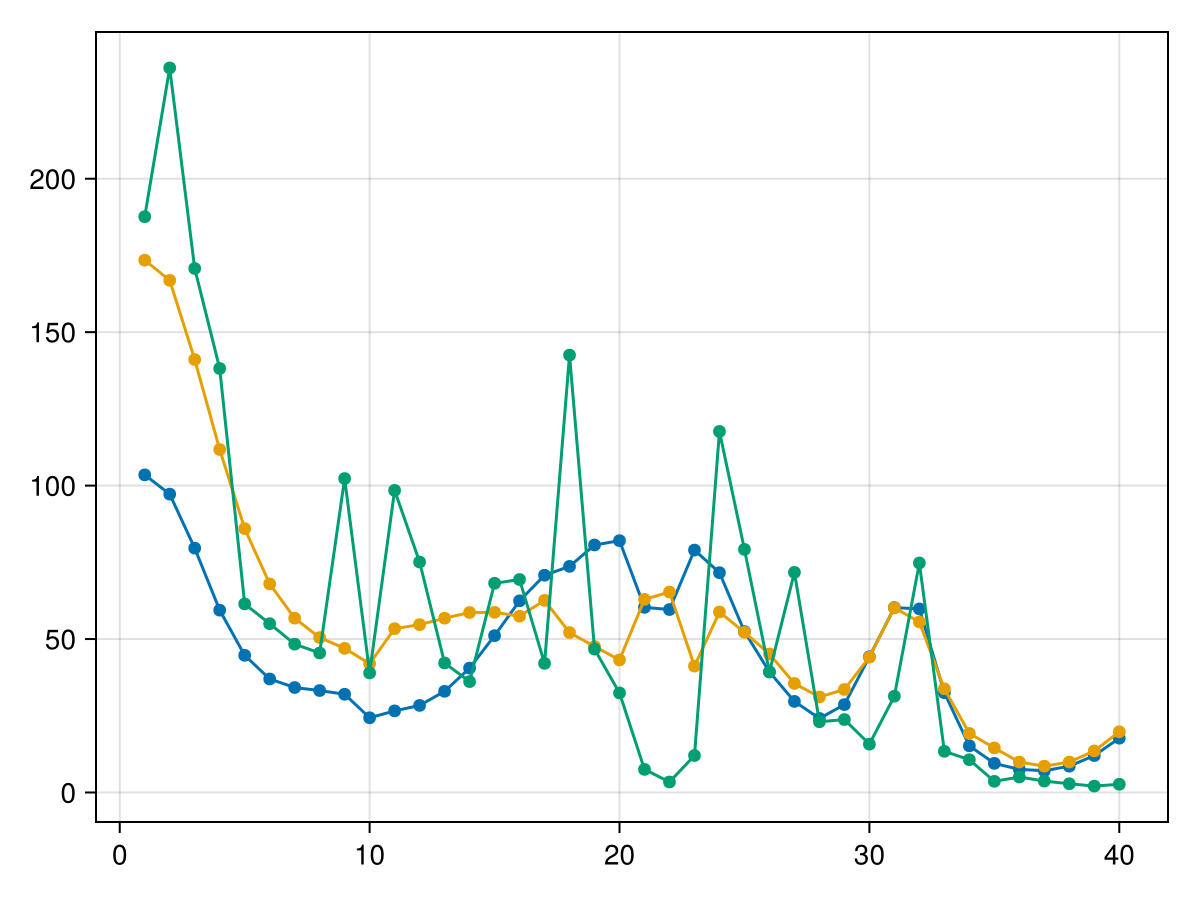

In [12]:
# fig = Figure()
# ax = Axis(fig[1,1])
lines!(ax,  [v for v in vdrude[2]])
scatter!(ax,  [v for v in vdrude[2]])
fig

In [158]:
13/2.46^2

2.1481922136294536

## Plots

In [75]:
using CairoMakie, LaTeXStrings, JLD2, Colors


In [149]:

using Interpolations, Statistics


#choose solution at boundary region
function interpolate_despike(x,y, threshold)
    good = detect_outliers(y, threshold)
    xg = x[good]
    yg = y[good]
    itp = linear_interpolation(xg, yg, extrapolation_bc = Line())
    return itp.(x)
end

function detect_outliers(data::AbstractVector{<:Real}, threshold::Real)
    n = length(data)
    good = trues(n)
    for i in 2:n-1
        avg_neighbors = (data[i-1] + data[i+1]) / 2
        if abs(data[i] - avg_neighbors) > threshold
            good[i] = false
        end
    end
    return good
end

function despike_forward!(d, threshold)
    data = zeros(length(d))
    n = length(data)
    data[1] = d[1]
    for i in 2:n-1
        left  = data[i-1]      # already filtered
        mid   = d[i]
        right = d[i+1]      # original (not yet filtered)

        avg_neighbors = (left + right) / 2
        deviation = abs(mid - avg_neighbors)

        if deviation > threshold && abs(right)-abs(mid) > threshold && abs(left)-abs(mid) > threshold || deviation > 10threshold
        data[i] = avg_neighbors
        else 
            data[i] = d[i]
        end
    end

    return data
end

function lat_tbg_figure( drudepresetpath, drudepath, lmcpresetpath, lmcpath, folder = 2281278; fontsize = 14)
    with_theme(merge(theme_latexfonts(), Theme(fontsize = fontsize))) do #
        tbg_figure( drudepresetpath, drudepath, lmcpresetpath, lmcpath, folder; fontsize = fontsize)   
    end
end

function tbg_figure(drudepresetpath, drudepath, lmcpresetpath, lmcpath, folder; fontsize = 12)
    figtbg = Figure(size = (600, 600))
    ax1 = Axis(figtbg[1,1], xlabel = "ν", ylabel = L"$|\langle \tau_z \rangle_\text{f}|$", xlabelsize = fontsize +2, ylabelsize = fontsize +2)
    ax2 = Axis(figtbg[2:3,1], xlabel = "ν", ylabel = L"$\sigma_{xxx}^{(S,1)}/\sigma_{xx}\text{ [1/T]}$", xlabelsize = fontsize +2, ylabelsize = fontsize +2)
    hidexdecorations!(ax1, grid = false)

    simportedvp = LMC.provide_folder_get_observables_atlas_reshuffled(folder,"vp")
    simportedqah = LMC.provide_folder_get_observables_atlas_reshuffled(folder,"qah")
    t1 = tauz(simportedvp)
    t2 = tauz(simportedqah)
    fig = Figure()
    
    col = parse(Colorant, "#FF34FFFF")
    lines!(ax1, simportedvp.ns, t1, label =  L"$\text{VP}" , color = col)
    lines!(ax1, simportedvp.ns, t2, label =  L"$\text{VH/SVH}$", color = :black)
    ylims!(ax1, -0.01, 2)
    axislegend(ax1, position = :lt)

    #_________________________________________#_________________________________________
    # νs, vals = aux_plot_tbg_obs(drudepresetpath, drudepath)
    νs, vals = aux_plot_tbg_obs(lmcpresetpath, lmcpath)

    y_interp = interpolate_despike( [ν for ν in νs],[obs for obs in vals], 50)

    # ylims!(ax2, -0.05,0.05)
    lines!(ax2, [ν for ν in νs],  y_interp)
    
    figtbg
end


function tauz(s::Self_consistent_data)
    taus = zeros(Float64,length(s.ofmats))
    for i in 1:length(s.ofmats)
        taus[i] = abs(sum(s.ofmats[i] .* [1, 1, -1, -1, 1, 1, -1, -1]))
    end
    taus
end

function BZdecorations!(p, ax)
    G1, G2 = LMC.bravais_vectors(p);     
    K1 =  LMC.κ(G1, G2)
    K2 =  LMC.κ(G2, G1)
    scatter!(ax, K1[1], K1[2], color = :red, marker = :x, markersize = 10)
    scatter!(ax, K2[1], K2[2], color = :blue, marker = :x, markersize = 10)
    scatter!(ax, K1[1]-G1[1], K1[2]-G1[2], color = :red, marker = :x, markersize = 10)
    scatter!(ax, K1[1]-G2[1]-G1[1], K1[2]-G2[2]-G1[2], color = :red, marker = :x, markersize = 10)
    scatter!(ax, K1[1]-G2[1], K1[2]-G2[2], color = :red, marker = :x, markersize = 10)
    scatter!(ax, K2[1]-G2[1], K2[2]-G2[2], color = :blue, marker = :x, markersize = 10)
    scatter!(ax, K2[1]-G1[1]-G2[1], K2[2]-G1[2]-G2[2], color = :blue, marker = :x, markersize = 10)
    scatter!(ax, [0, G1[1],G2[1],-G1[1],-G2[1],G1[1]+G2[1],-G1[1]-G2[1]], 
             [0,G1[2],G2[2],-G1[2],-G2[2],G1[2]+G2[2],-G1[2]-G2[2]], 
            color = :black, marker = :x, markersize = 10)
    lines!(ax, [0, G1[1], G1[1]+G2[1], G2[1] , 0], 
             [0, G1[2],  G1[2]+G2[2], G2[2] , 0], 
            color = :black, linestyle = :dash)
end


BZdecorations! (generic function with 1 method)

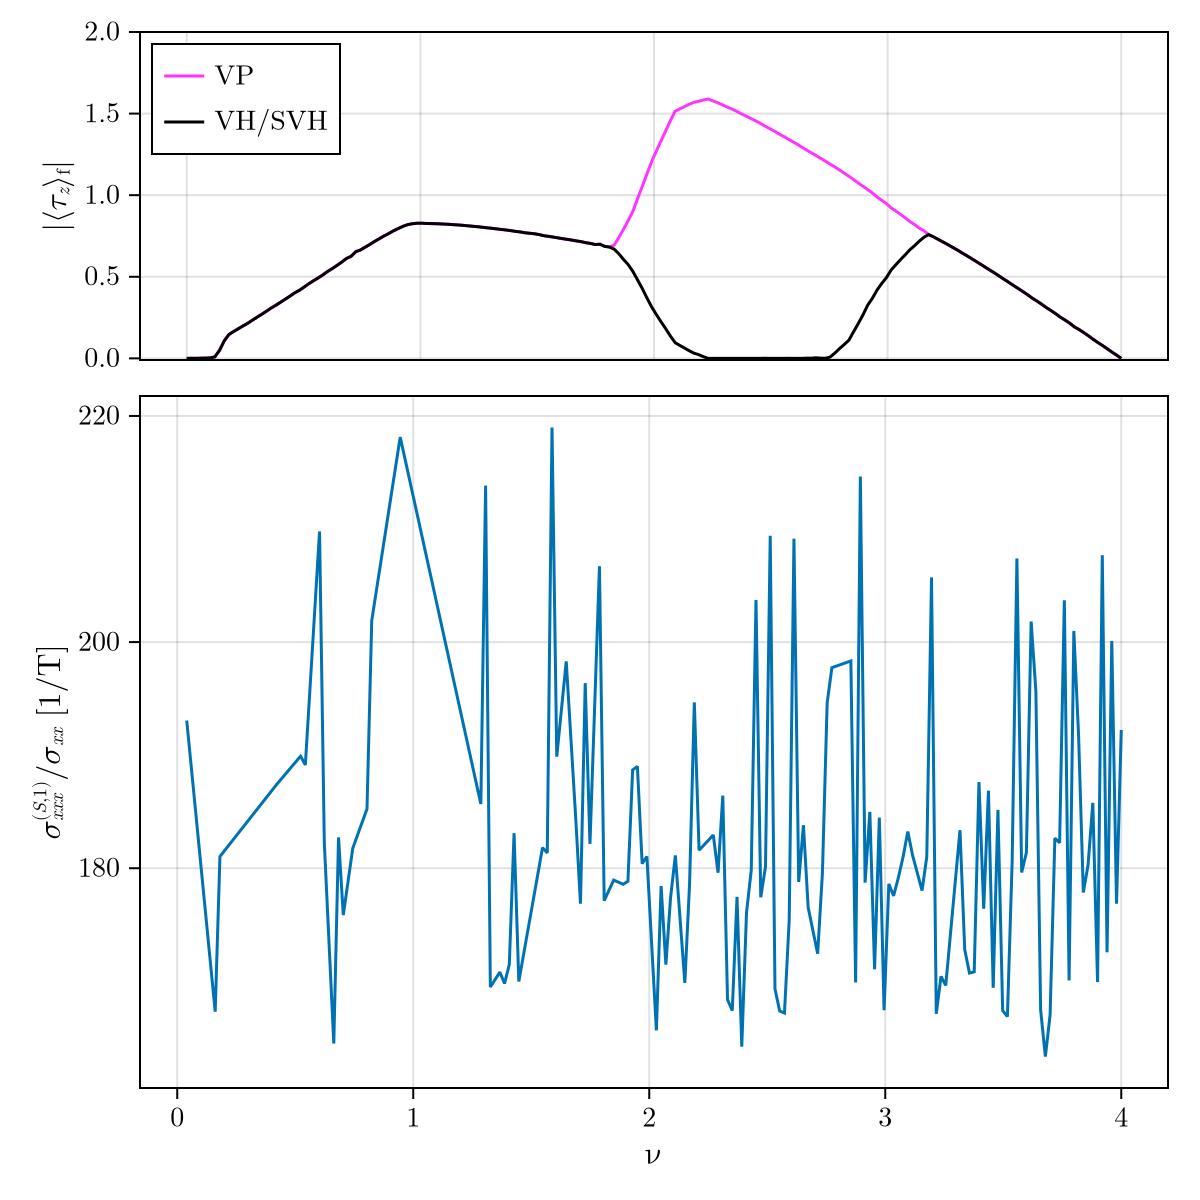

In [150]:
lat_tbg_figure(drudepresetpath, drudepath, lmcpresetpath, lmcpath)

(Any[0.0, 0.020100502512562814, 0.04020100502512563, 0.06030150753768844, 0.08040201005025126, 0.10050251256281408, 0.12060301507537688, 0.1407035175879397, 0.16080402010050251, 0.18090452261306533  …  3.819095477386935, 3.8391959798994977, 3.85929648241206, 3.879396984924623, 3.899497487437186, 3.919597989949749, 3.9396984924623117, 3.959798994974874, 3.979899497487437, 4.0], Any[0.0005536940822230287, 1.3764756594131754e-6, 0.0, 2.9189453949132266e-23, 0.0005753007414085192, 0.0006328394146331893, 5.121037041014542e-8, 0.0, 0.0014530406055918127, 0.006519978533268918  …  0.0038805981717614365, 8.375949266384057e-18, 3.987166525566778e-5, 8.750047097680101e-7, 0.00014076764691515144, 0.005679141313032551, 7.407109300840577e-6, 1.1245520979698343e-5, 8.574625418251678e-52, 1.5637874696503365e-21])

In [147]:
y_interp = interpolate_despike( [ν for ν in νs],v, 80)
using Interpolations

In [148]:
y_interp

200-element Vector{Float64}:
 76.8880745647023
 79.97980911524468
 83.07154366578706
 31.403817937449087
 23.57435111413298
 70.7992371222872
 22.81551927075506
 86.04849090636564
 46.24109346204932
 32.89235926528871
  ⋮
 78.54750700685872
 71.66389995312079
 64.78029289938272
 43.393432019510115
 50.95516817168751
 42.694005524297665
 30.113083690322814
 83.30452577604483
 54.284438352927324

In [163]:
# HYP Drudes: 
drude_vec = [4637376]
# HYP LMC: [ 4616767, 4617898 , 4618700,  4619343]
lmc_vec = [4655329, 4652639,4651517,4650903,4650379,4649541,4648753]

#out put response calculations
drudePID = drude_vec[1]#4619927#4612639 #4604805
lmcPID = lmc_vec[1]

drudepath = "/Users/fernandopenaranda/Documents/Work/PostdocDonosti/Packages/LMC/src/Paper/ClusterTBG/output/LMC/$(drudePID)_merged_data.jld"
drudepresetpath = "/Users/fernandopenaranda/Documents/Work/PostdocDonosti/Packages/LMC/src/Paper/ClusterTBG/output/LMC/$(drudePID)_merged_presets.jld"
lmcpath = "/Users/fernandopenaranda/Documents/Work/PostdocDonosti/Packages/LMC/src/Paper/ClusterTBG/output/LMC/$(lmcPID)_merged_data.jld"
lmcpresetpath = "/Users/fernandopenaranda/Documents/Work/PostdocDonosti/Packages/LMC/src/Paper/ClusterTBG/output/LMC/$(lmcPID)_merged_presets.jld"


"/Users/fernandopenaranda/Documents/Work/PostdocDonosti/Packages/LMC/src/Paper/ClusterTBG/output/LMC/4655329_merged_presets.jld"

In [164]:
νs, vals = aux_plot_tbg_obs(lmcpresetpath, lmcpath)

(Any[0.0, 0.020100502512562814, 0.04020100502512563, 0.06030150753768844, 0.08040201005025126, 0.10050251256281408, 0.12060301507537688, 0.1407035175879397, 0.16080402010050251, 0.18090452261306533  …  3.819095477386935, 3.8391959798994977, 3.85929648241206, 3.879396984924623, 3.899497487437186, 3.919597989949749, 3.9396984924623117, 3.959798994974874, 3.979899497487437, 4.0], Any[0.00734005031571599, 0.06136501241776696, 0.0037150396890558673, 0.0023401463528735173, 0.00019132838150650664, 0.00048565140907882797, 0.0046619709493812425, 0.003720710802534254, 0.022202166843886137, 0.010467138871635803  …  0.037428495857213494, 0.007273295980541842, 0.0010962994270106263, 0.04840734931629278, 0.005582173903558919, 0.00424892147293919, 0.0016480365615801837, 0.002261171474230182, 0.006141149010802994, 0.042125288903634955])

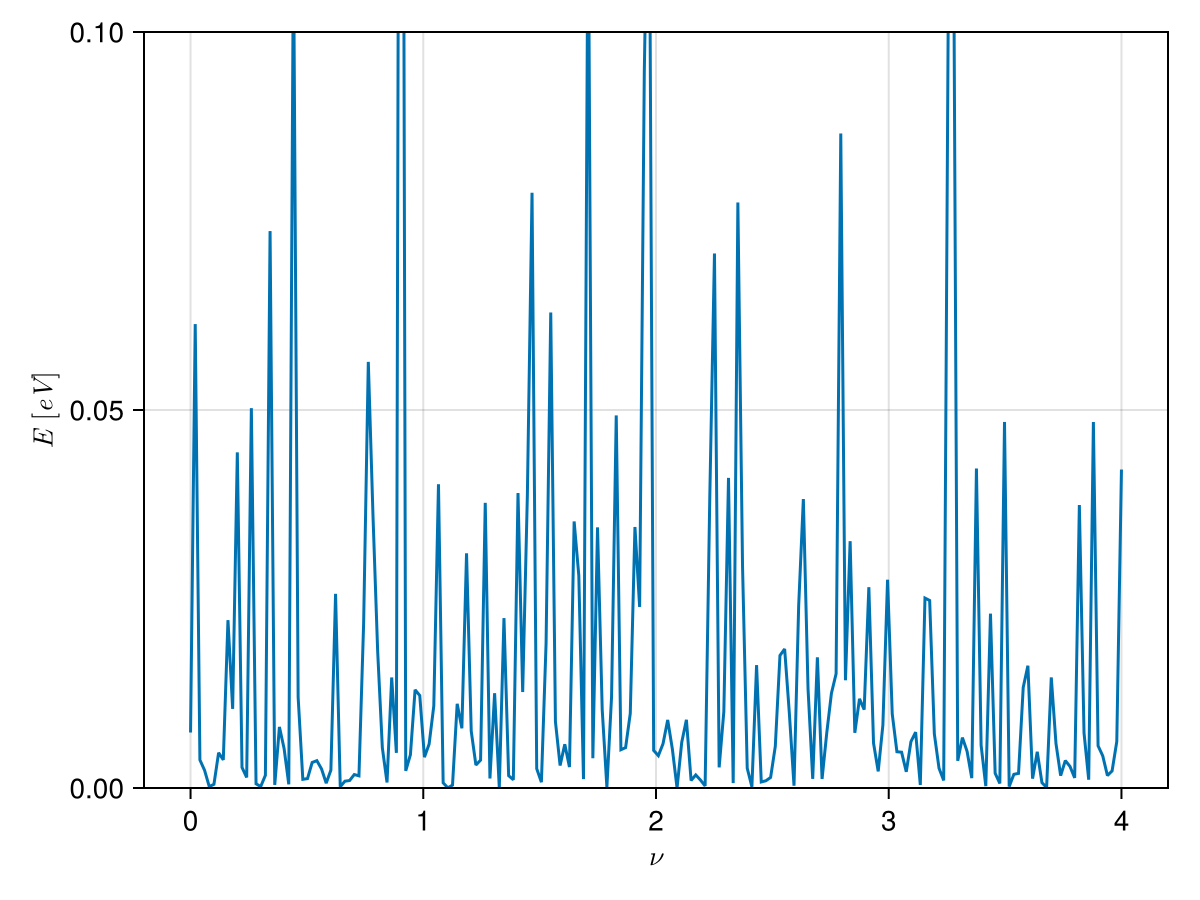

In [166]:

fig = Figure()
ax = Axis(fig[1,1], xlabel = L"$\nu$", ylabel = L"$E\text{ }[eV]$")
nus = [ν for ν in νs]
v = [obs for obs in vals]
# ylims!(ax, -0.05,0.05)
y_interp = interpolate_despike( [ν for ν in νs],v, 80)
using Interpolations
Interpolations.interpolate((nus,), (v), Gridded(Linear()))
ylims!(ax, 0, 0.1)
lines!(ax, nus ,y_interp)
fig


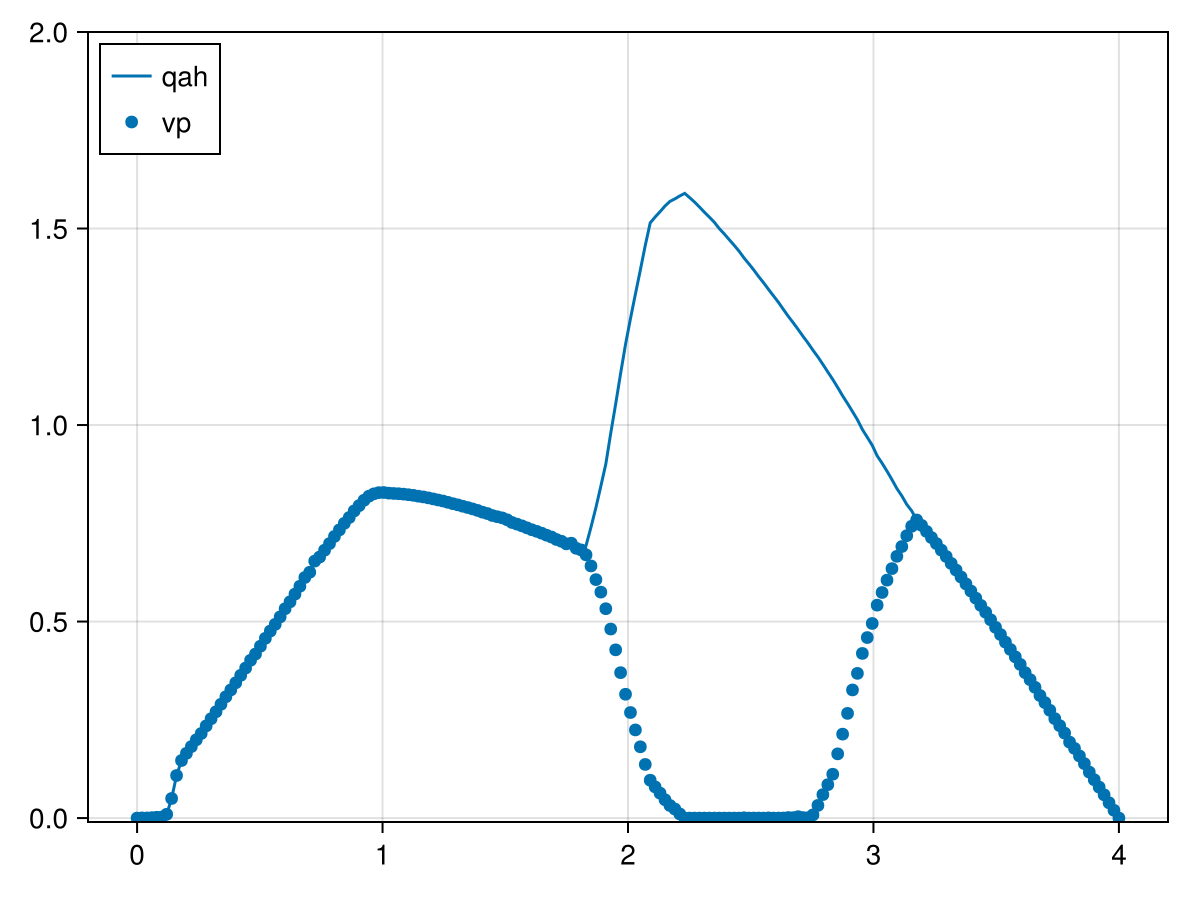

In [172]:
#input self-consistent data (band structures and fillings)
folder = 2281278
simportedvp = LMC.provide_folder_get_observables_atlas_reshuffled(folder,"vp")
simportedqah = LMC.provide_folder_get_observables_atlas_reshuffled(folder,"qah")

function tauz(s::Self_consistent_data)
    taus = zeros(Float64,length(s.ofmats))
    for i in 1:length(s.ofmats)
        taus[i] = abs(sum(s.ofmats[i] .* [1, 1, -1, -1, 1, 1, -1, -1]))
    end
    taus
end
t1 = tauz(simportedvp)
t2 = tauz(simportedqah)
fig = Figure()
ax = Axis(fig[1,1]) 
lines!(ax, simportedvp.ns, t1, label = "qah")
scatter!(ax, simportedvp.ns, t2, label = "vp")
ylims!(ax, -0.01, 2)
axislegend(ax, position = :lt)
fig

## Tests

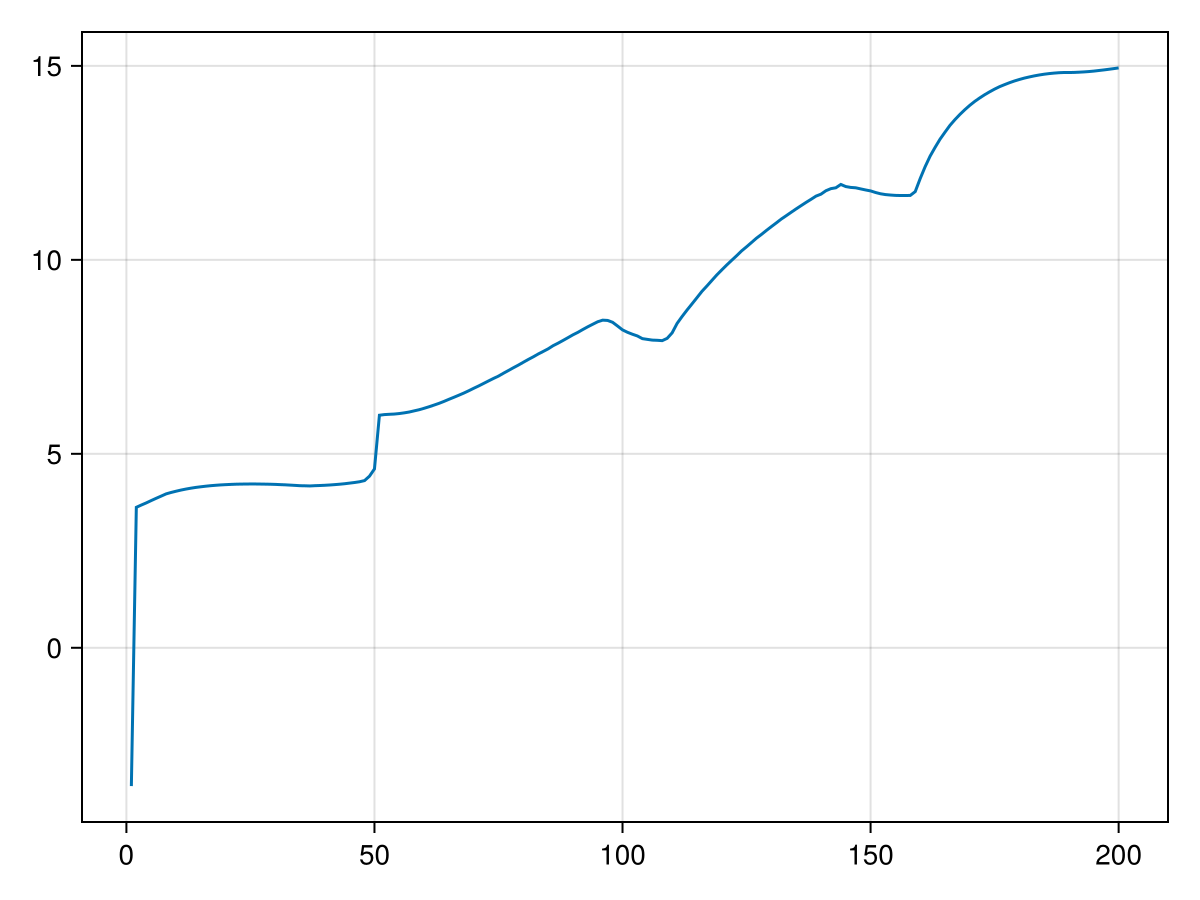

In [21]:
fig = Figure()
ax = Axis(fig[1,1])
lines!(ax, simportedvp.mus)
fig

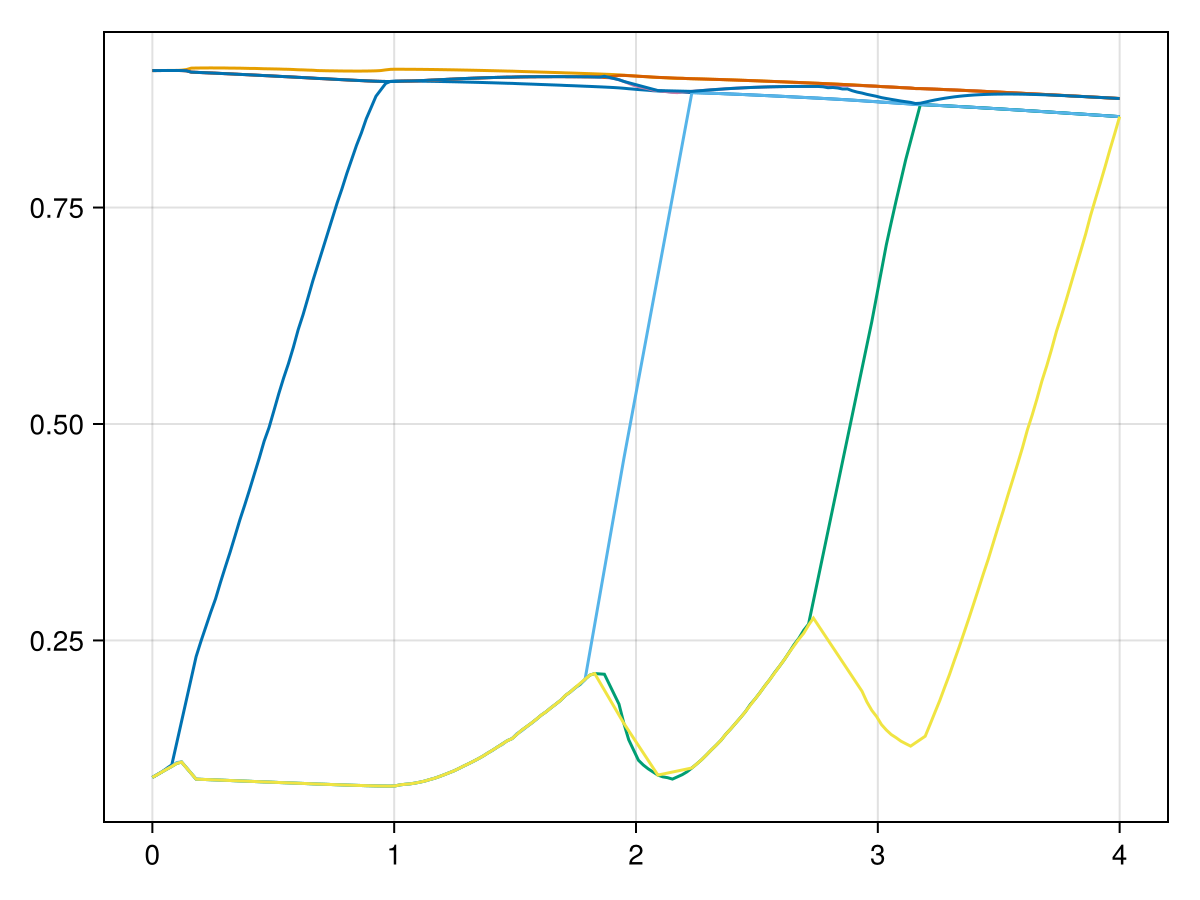

In [114]:
fig = Figure()
ax = Axis(fig[1,1])
s = simportedvp

[lines!(ax, s.ns, intnss[it]) for it in 1:8]
fig
# lines!(ax, simportedqah.ofmats[8])

In [89]:
"""
self-consistent magnetoconductivity sweep with filling
"""
function mc_sweep(p, s::Self_consistent_data; evals = 10, T=1)
    mc_arr = []
    for (it,ν) in enumerate(s.ns)
        if it % 10 == 0
            prs = xxx_lmc_presets(ParamsHF(pimported, μ = s.mus[it]), diagm(s.ofmats[it]), T = T, evals = evals)
            mc = linear_magneto_conductivity_orbital(prs)
            append!(mc_arr, mc)
            println("progress: ", it/length(s.ns)," |  val: ", mc)
        end
    end
    return s.ns, mc_arr
end

mc_sweep

In [90]:
@time ns, mcqah = mc_sweep(pimported, simportedqah, T = 1000, evals = 1000)
    

progress: 0.05 |  val: 0.007445122653333354
progress: 0.1 |  val: 0.007203439664739912
progress: 0.15 |  val: 0.007652735916616184
progress: 0.2 |  val: 0.006256052895803186
progress: 0.25 |  val: 0.006372928688283411
progress: 0.3 |  val: 0.001199742751498212
progress: 0.35 |  val: 0.0010982067617763594
progress: 0.4 |  val: -0.0012180969704891418
progress: 0.45 |  val: 0.0028160957773728343
progress: 0.5 |  val: 0.008215652670132108
progress: 0.55 |  val: 0.0007379576914120238
progress: 0.6 |  val: -0.0010617957239967722
progress: 0.65 |  val: -0.00012851626951724122
progress: 0.7 |  val: 0.0012173675704670597
progress: 0.75 |  val: 0.002624283328581628
progress: 0.8 |  val: 0.0028699731423258274
progress: 0.85 |  val: 0.004961144735417598
progress: 0.9 |  val: 0.0055929647820608915
progress: 0.95 |  val: 0.005911396576148802
progress: 1.0 |  val: 0.0022569371553927222
824.051065 seconds (74.75 M allocations: 380.134 GiB, 6.38% gc time, 0.00% compilation time)


([0.0, 0.020100502512562814, 0.04020100502512563, 0.06030150753768844, 0.08040201005025126, 0.10050251256281408, 0.12060301507537688, 0.1407035175879397, 0.16080402010050251, 0.18090452261306533  …  3.819095477386935, 3.8391959798994977, 3.85929648241206, 3.879396984924623, 3.899497487437186, 3.919597989949749, 3.9396984924623117, 3.959798994974874, 3.979899497487437, 4.0], Any[0.007445122653333354, 0.007203439664739912, 0.007652735916616184, 0.006256052895803186, 0.006372928688283411, 0.001199742751498212, 0.0010982067617763594, -0.0012180969704891418, 0.0028160957773728343, 0.008215652670132108, 0.0007379576914120238, -0.0010617957239967722, -0.00012851626951724122, 0.0012173675704670597, 0.002624283328581628, 0.0028699731423258274, 0.004961144735417598, 0.0055929647820608915, 0.005911396576148802, 0.0022569371553927222])

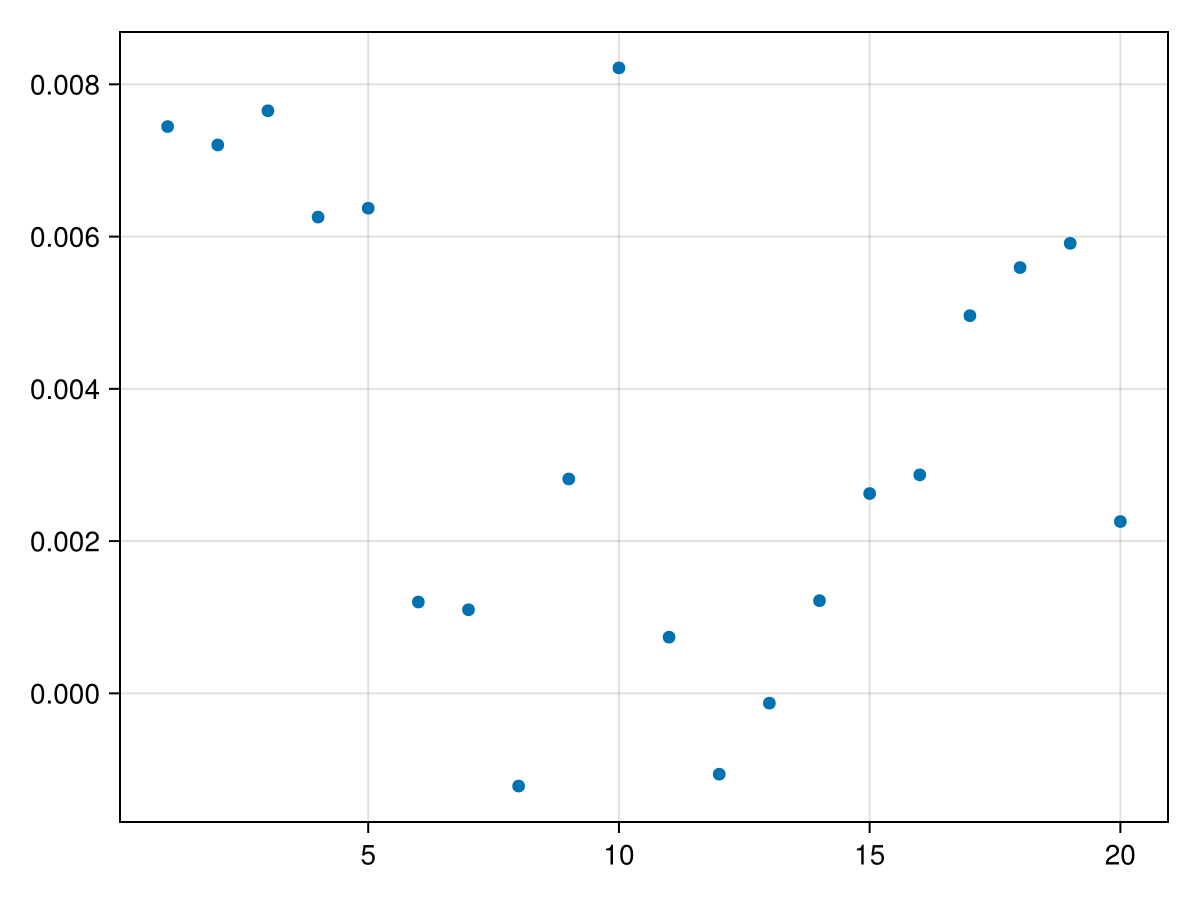

In [92]:
fig = Figure()
ax = Axis(fig[1,1])
scatter!(ax,  [m for m in mcqah])
fig

In [64]:
p = pimported
M, xmin, xmax = LMC.int_boundaries(p)
xbounds = [0, xmin[2]]
ybounds = [xmax[1]/2, xmax[2]]

2-element Vector{Float64}:
 0.027023694543358623
 0.046806411957319716

2-element Vector{Float64}:
  0.0
 -0.046806411957319716

### Test FS

In [118]:
# Define number of grid points
T = 5 * 1e3
νval = 2.5
it = argmin(abs.(s.ns .- νval))
n = 50
p = pimported
svp = simportedvp
sqah = simportedqah

pxxxvp = xxx_lmc_presets(ParamsHF(p, μ = svp.mus[it]), diagm(svp.ofmats[it]), T = T, fermi_surface = true) 
integrandvp(q) = Optics_in_the_length_gauge.k_linear_magneto_conductivity_orbital(pxxxvp, q) 

pxxxqah = xxx_lmc_presets(ParamsHF(p, μ = sqah.mus[it]), diagm(sqah.ofmats[it]), T = T, fermi_surface = true) 
integrandqah(q) = Optics_in_the_length_gauge.k_linear_magneto_conductivity_orbital(pxxxqah, q) 


M, xmin, xmax = LMC.int_boundaries(p)
# a = [0, xmin[2]];
# b = [xmax[1]/2, xmax[2]];
a = [-xmax[1], xmin[2]];
b = [xmax[1], xmax[2]];

# Generate grid points
x = range(a[1], b[1], length=n)
y = range(a[2], b[2], length=n)

# Evaluate f on the grid
Zvp = [integrandvp([xi, yi]) for xi in x, yi in y];  # notice: [row, column] ordering
Zqah = [integrandqah([xi, yi]) for xi in x, yi in y];  # notice: [row, column] ordering

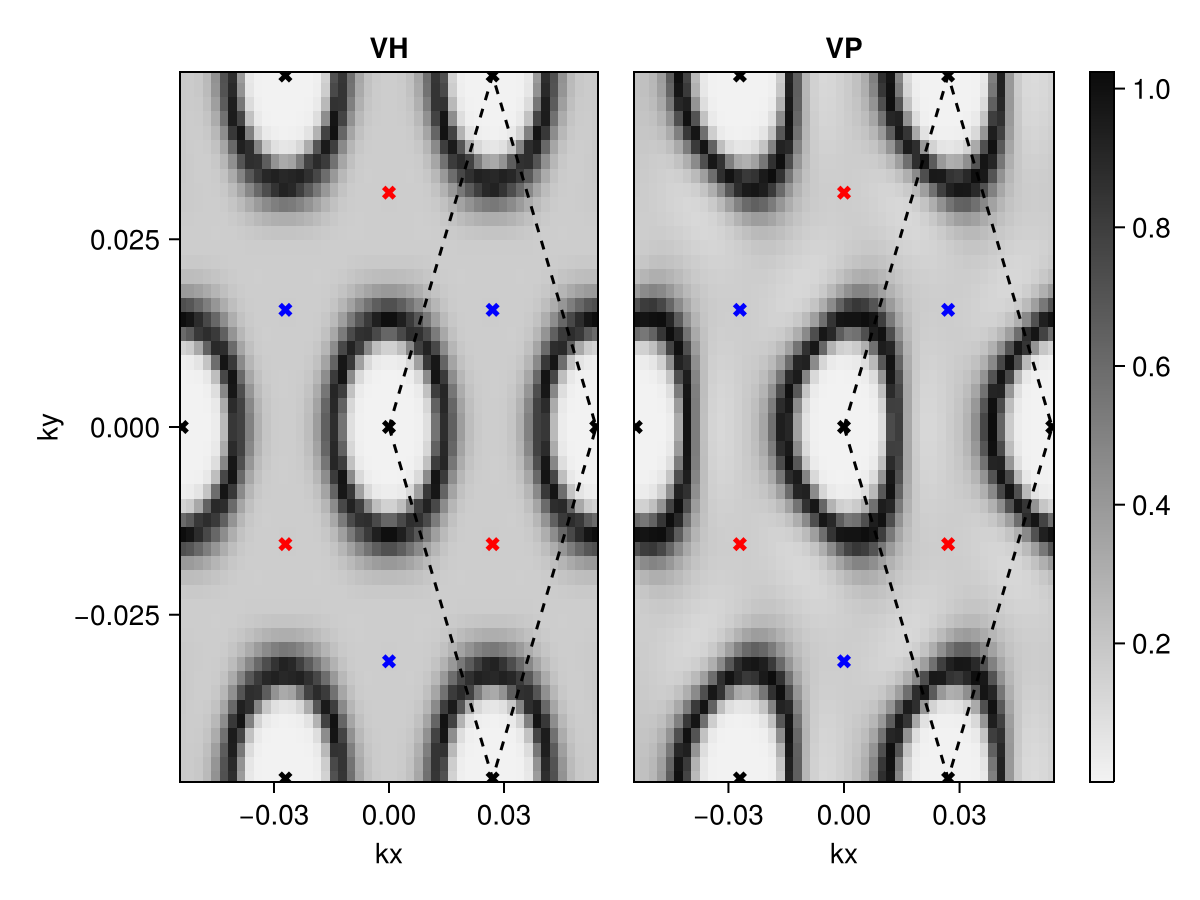

In [130]:

# Create the density plot
using CairoMakie
fig = Figure()
vis = 1e21
ϵ = abs(xmin[2])/100
ax1 = Axis(fig[1, 1], xlabel="kx", ylabel="ky", title="VH")
ax2 = Axis(fig[1, 2], xlabel="kx", ylabel="ky", title="VP")
val = maximum(abs.(Zqah))
# heatmap!(ax, x, y, Z, colormap=:redsblues)#, colorrange=(-1, 1.0).*vis)
hm = heatmap!(ax1, x, y, -Zqah ./val, colormap=Reverse(:grays))#, colorrange=(-1, 0).*vis)
BZdecorations!(p, ax1)

hm = heatmap!(ax2, x, y, -Zvp ./ val, colormap=Reverse(:grays))#, colorrange=(-1, 0).*vis)
BZdecorations!(p, ax2)
xlims!(ax1, a[1]-ϵ, b[1]+ϵ)
ylims!(ax1, a[2]-ϵ, b[2]+ϵ)

xlims!(ax2, a[1]-ϵ, b[1]+ϵ)
ylims!(ax2, a[2]-ϵ, b[2]+ϵ)
cb = Colorbar(fig[1, 3], hm)
hideydecorations!(ax2)

# Colorbar(fig[1,2], ax)  # Add a colorbar
fig

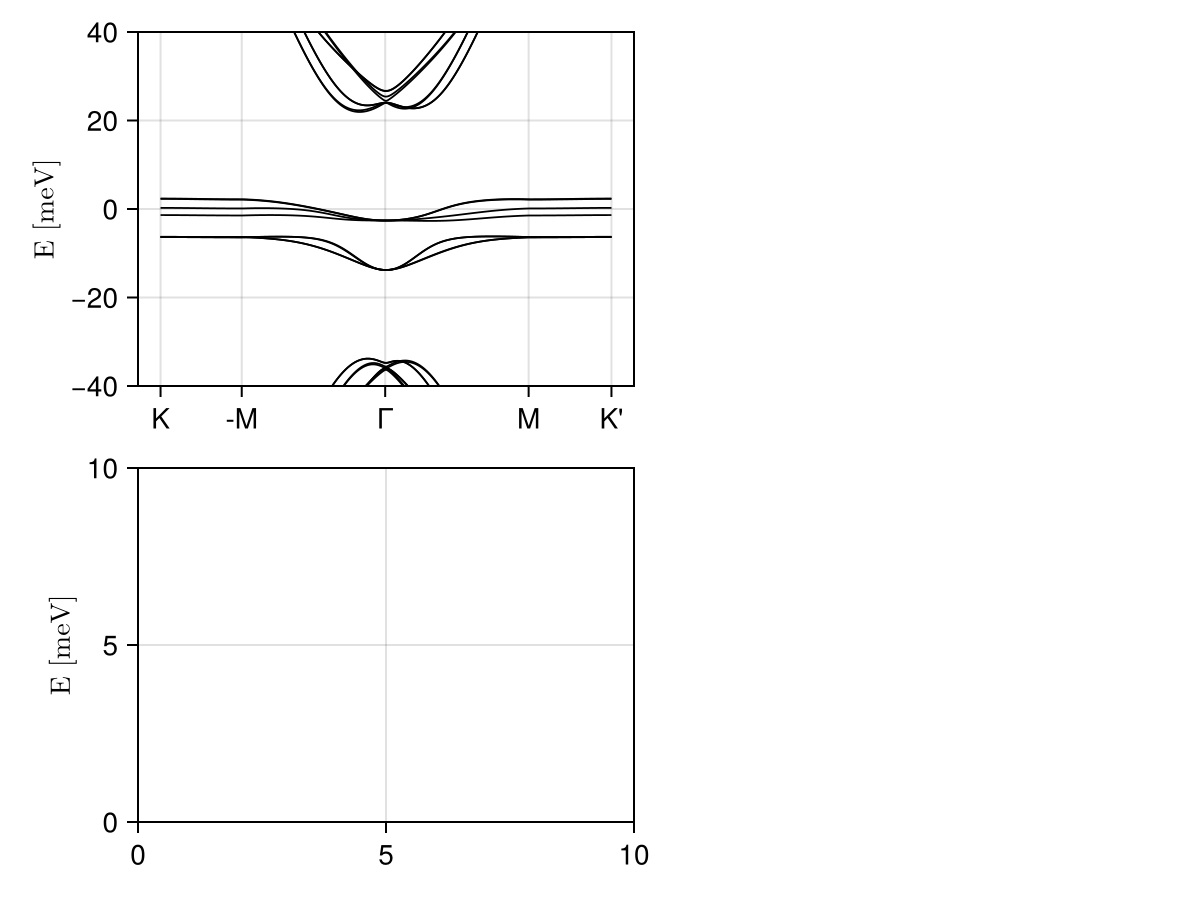

In [82]:

it = 100

fig = Figure()
ax1 = Axis(fig[1,1], ylabel = L"$\text{E [meV]}$")
ax2 = Axis(fig[2,1], ylabel = L"$\text{E [meV]}$")
ga = fig[1:2,2] = GridLayout()

LMC.plotmybands!(ax1, real.(LMC.bands(ParamsHF(p, μ = s.mus[it]), diagm(s.ofmats[it]), 101)),
      ylimits = [-40,40], color = :black)
# LMC.plotmybands!(ax2, real.(LMC.bands(ParamsHF(p, μ = 0, sigmaz = 5), ones(8),  101)), 
#       ylimits = ylims, xlimits = xlimits, color = :black, linewidth = linewidth)
    
    
fig
